In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from model import TwistGraphite

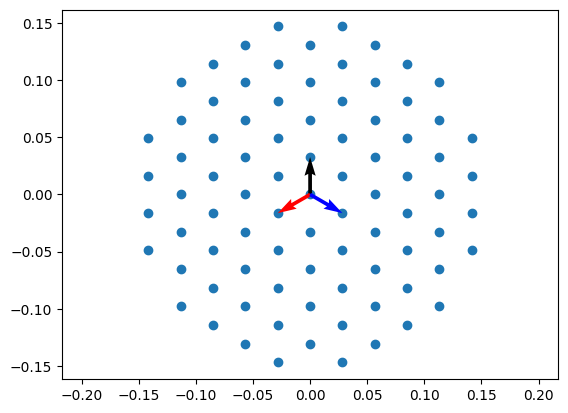

In [50]:
model=TwistGraphite(theta=1.1)
model.init_mesh(ecut=1)
model.plot_mesh()

100%|██████████| 120/120 [00:00<00:00, 159.20it/s]


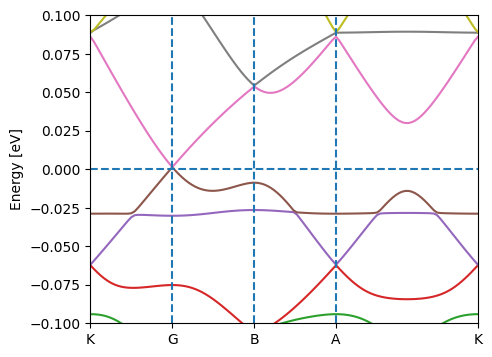

In [51]:
model.plot_bandstructure()

100%|██████████| 120/120 [00:00<00:00, 184.82it/s]


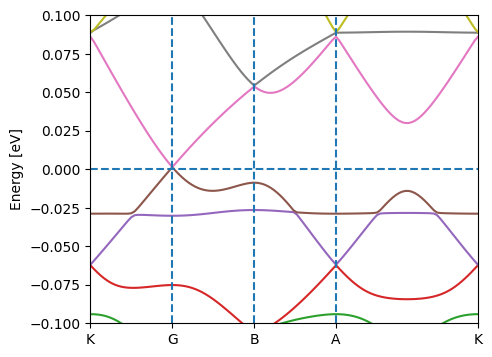

In [52]:
model.plot_bandstructure(kz=2/3)

In [53]:
h=model.hamiltonian(kz=0)
e,u=np.linalg.eigh(h)

In [54]:
e[model.N+1]

0.001375931109894579

In [55]:
psi=u[:,model.N+1]

In [56]:
psi_r=model.ifft(psi)
abs_r=np.abs(psi_r)**2

In [59]:
e=[]
kz=np.linspace(-0.5,0.5,401)
for k in kz:
    h=model.hamiltonian(kz=k)
    e.append(np.linalg.eigvalsh(h))

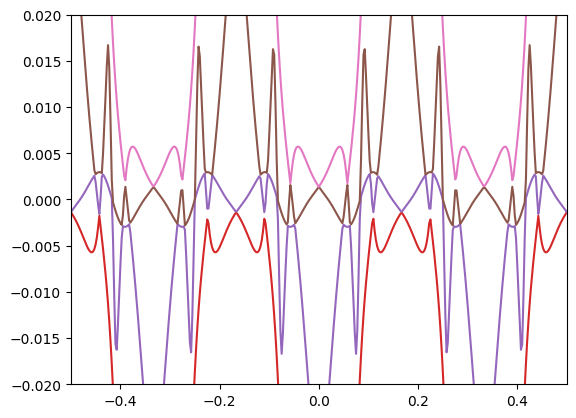

In [62]:
plt.figure()
plt.plot(kz,e)
plt.ylim([-0.02,0.02])
plt.xlim([-0.5,0.5])
plt.show()

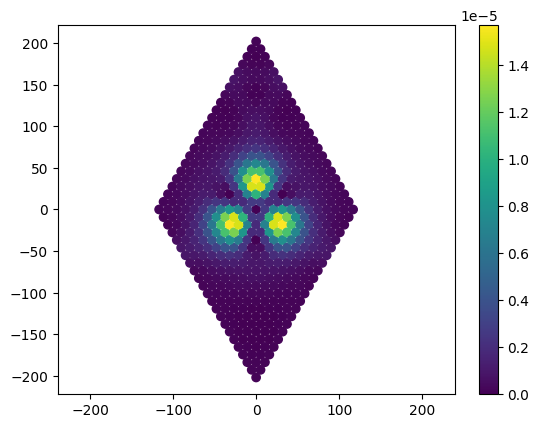

In [44]:
plt.figure()
plt.scatter(model.r[0],model.r[1],c=abs_r[:,:,1])
plt.colorbar()
plt.axis('equal')
plt.show()

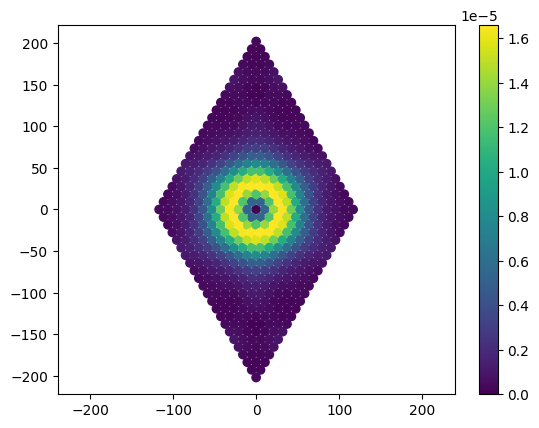

In [41]:
plt.figure()
plt.scatter(model.r[0],model.r[1],c=abs_r.sum(axis=-1))
plt.colorbar()
plt.axis('equal')
plt.show()

In [29]:
psi_k=model.fft(psi_r)